# [Code](https://youtu.be/a20TaKNsriE?list=PLKnIA16_Rmvbr7zKYQuBfsVkjoLcJgxHH)

In [157]:
import numpy as np
import pandas as pd
from mlxtend.plotting import plot_decision_regions

In [158]:
df = pd.DataFrame()

In [159]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [160]:
df.head()

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0


<Axes: xlabel='X1', ylabel='X2'>

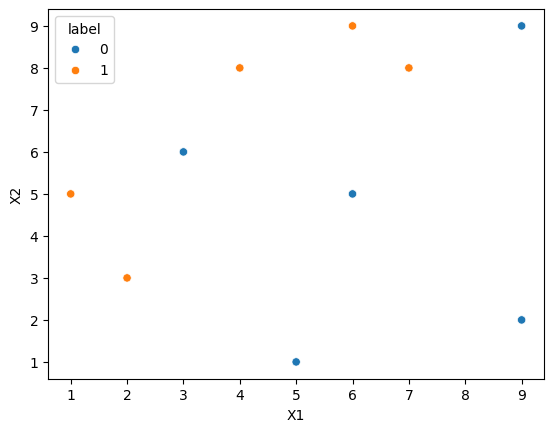

In [161]:
import seaborn as sns
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [162]:
# Step1: assign equal weights to all samples  
df['weights'] = 1/df.shape[0]

In [163]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [164]:
from sklearn.tree import DecisionTreeClassifier

In [165]:
dt1 = DecisionTreeClassifier(max_depth=1)


In [166]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-2].values

In [167]:
# Step2: train decision stump
dt1.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [168]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

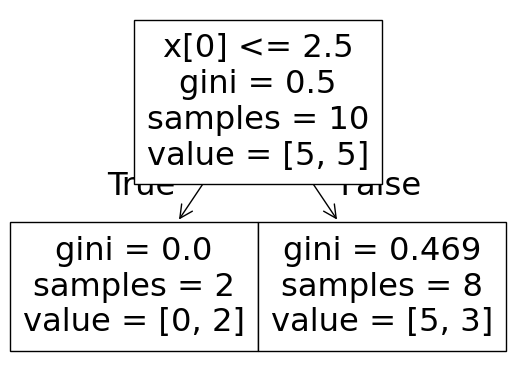

In [169]:
plot_tree(dt1)

<Axes: >

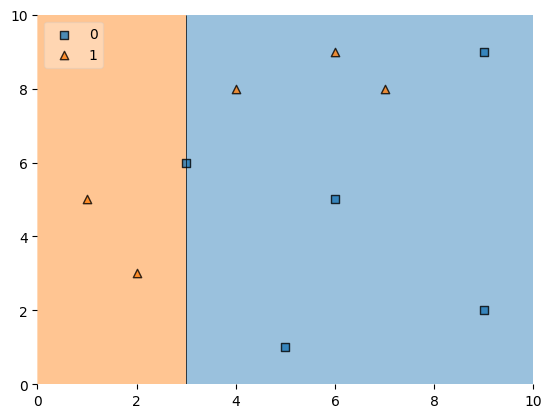

In [170]:
plot_decision_regions(X=X,y=y,clf=dt1,legend=2)

In [171]:
df['y_pred'] = dt1.predict(X)

In [172]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [173]:
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/error)

In [174]:
error = sum(df[df['label'] != df['y_pred']]['weights'].values) #sum of weights where model was wrong.

In [175]:
# Step 3 -- calculate model's weightage constant.
alpha = calculate_model_weight(error)
alpha

np.float64(0.4236489301936017)

In [176]:
def update_weights(row,alpha=alpha):
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)

In [177]:
df['updated_weights']=df.apply(update_weights,axis=1)

In [178]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065465
1,2,3,1,0.1,1,0.065465
2,3,6,0,0.1,0,0.065465
3,4,8,1,0.1,0,0.152753
4,5,1,0,0.1,0,0.065465
5,6,9,1,0.1,0,0.152753
6,6,5,0,0.1,0,0.065465
7,7,8,1,0.1,0,0.152753
8,9,9,0,0.1,0,0.065465
9,9,2,0,0.1,0,0.065465


In [179]:
np.sum(df['updated_weights'])

np.float64(0.9165151389911681)

In [180]:
# normalization:  
df['normalized_weights'] = df['updated_weights']/(df['updated_weights']).sum()


In [181]:
# ranges:
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])

In [182]:
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']

In [183]:
df[['X1','X2','label','weights','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,0.065465,0.000000,0.071429
1,2,3,1,0.1,0.065465,0.071429,0.142857
2,3,6,0,0.1,0.065465,0.142857,0.214286
3,4,8,1,0.1,0.152753,0.214286,0.380952
4,5,1,0,0.1,0.065465,0.380952,0.452381
5,6,9,1,0.1,0.152753,0.452381,0.619048
6,6,5,0,0.1,0.065465,0.619048,0.690476
7,7,8,1,0.1,0.152753,0.690476,0.857143
8,9,9,0,0.1,0.065465,0.857143,0.928571
9,9,2,0,0.1,0.065465,0.928571,1.000000


In [184]:
def new_dataset(df):
    indices= []

    for i in range(df.shape[0]):
        random = np.random.random()
        print(random)
        for index,row in df.iterrows():
            if row['cumsum_lower'] < random and row['cumsum_upper'] > random:
                indices.append(index)
                
    return indices
    

In [185]:
ind = new_dataset(df)
ind

0.059533734149179285
0.029150616568416554
0.9622276113802704
0.5181252775013511
0.13856359253204575
0.28545879353613657
0.3789603176353544
0.10227072958142946
0.38087513841959897
0.15671793825325486


[0, 0, 9, 5, 1, 3, 3, 1, 3, 2]

In [186]:
df2 = df.iloc[ind,[0,1,2,3]]
df2

,X1,X2,label,weights
0,1,5,1,0.1
0,1,5,1,0.1
9,9,2,0,0.1
5,6,9,1,0.1
1,2,3,1,0.1
3,4,8,1,0.1
3,4,8,1,0.1
1,2,3,1,0.1
3,4,8,1,0.1
2,3,6,0,0.1


In [187]:
dt2 = DecisionTreeClassifier(max_depth=1)
X = df2.iloc[:,0:2].values
y = df2.iloc[:,-2].values

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.32\nsamples = 10\nvalue = [2, 8]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.625, 0.5, '  False')]

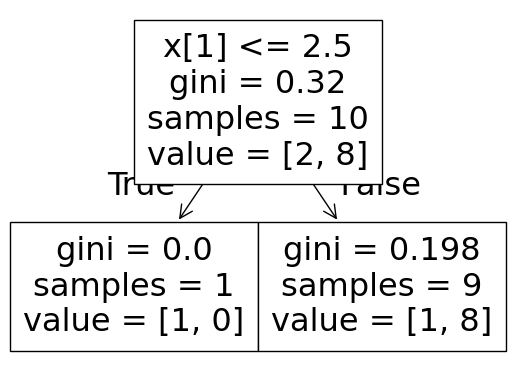

In [188]:
dt2.fit(X,y)
plot_tree(dt2)

<Axes: >

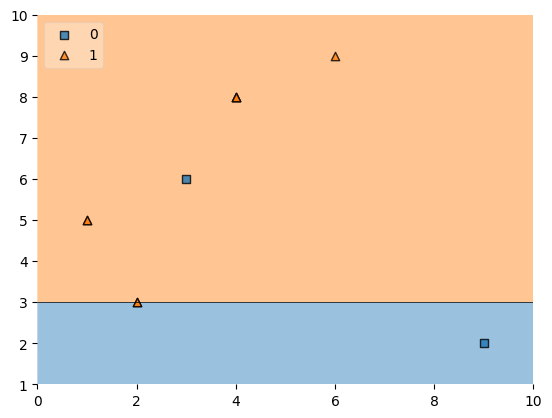

In [189]:
plot_decision_regions(X,y,clf=dt2,legend=2)

In [190]:
df2['y_pred'] = dt2.predict(X)
df2

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
0,1,5,1,0.1,1
9,9,2,0,0.1,0
5,6,9,1,0.1,1
1,2,3,1,0.1,1
3,4,8,1,0.1,1
3,4,8,1,0.1,1
1,2,3,1,0.1,1
3,4,8,1,0.1,1
2,3,6,0,0.1,1


In [195]:
error2 = sum(df2[df2['label'] != df2['y_pred']]['weights'].values)

In [196]:
alpha2 = calculate_model_weight(error2)
alpha2

np.float64(1.0986122886681098)

In [197]:
def update_weights(row,alpha=alpha2):
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)

In [200]:
df2['updated_weights'] = df2.apply(update_weights,axis=1)
df2

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.033333,0.055556
0,1,5,1,0.1,1,0.033333,0.055556
9,9,2,0,0.1,0,0.033333,0.055556
5,6,9,1,0.1,1,0.033333,0.055556
1,2,3,1,0.1,1,0.033333,0.055556
3,4,8,1,0.1,1,0.033333,0.055556
3,4,8,1,0.1,1,0.033333,0.055556
1,2,3,1,0.1,1,0.033333,0.055556
3,4,8,1,0.1,1,0.033333,0.055556
2,3,6,0,0.1,1,0.300000,0.500000


In [201]:
df2['normalized_weights'] = df2['updated_weights']/df2['updated_weights'].sum()
df2

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.033333,0.055556
0,1,5,1,0.1,1,0.033333,0.055556
9,9,2,0,0.1,0,0.033333,0.055556
5,6,9,1,0.1,1,0.033333,0.055556
1,2,3,1,0.1,1,0.033333,0.055556
3,4,8,1,0.1,1,0.033333,0.055556
3,4,8,1,0.1,1,0.033333,0.055556
1,2,3,1,0.1,1,0.033333,0.055556
3,4,8,1,0.1,1,0.033333,0.055556
2,3,6,0,0.1,1,0.300000,0.500000


In [202]:
df2['cumsum_upper'] = np.cumsum(df2['normalized_weights'])
df2['cumsum_upper'] 

0    0.055556
0    0.111111
9    0.166667
5    0.222222
1    0.277778
3    0.333333
3    0.388889
1    0.444444
3    0.500000
2    1.000000
Name: cumsum_upper, dtype: float64

In [203]:
df2['cumsum_lower'] = df2['cumsum_upper'] - df2['normalized_weights']
df2['cumsum_lower']

0    0.000000
0    0.055556
9    0.111111
5    0.166667
1    0.222222
3    0.277778
3    0.333333
1    0.388889
3    0.444444
2    0.500000
Name: cumsum_lower, dtype: float64

In [207]:
df2

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.033333,0.055556,0.055556,0.000000
0,1,5,1,0.1,1,0.033333,0.055556,0.111111,0.055556
9,9,2,0,0.1,0,0.033333,0.055556,0.166667,0.111111
5,6,9,1,0.1,1,0.033333,0.055556,0.222222,0.166667
1,2,3,1,0.1,1,0.033333,0.055556,0.277778,0.222222
3,4,8,1,0.1,1,0.033333,0.055556,0.333333,0.277778
3,4,8,1,0.1,1,0.033333,0.055556,0.388889,0.333333
1,2,3,1,0.1,1,0.033333,0.055556,0.444444,0.388889
3,4,8,1,0.1,1,0.033333,0.055556,0.500000,0.444444
2,3,6,0,0.1,1,0.300000,0.500000,1.000000,0.500000


In [204]:
def new_dataset2(df):
    indices = []
    for i in range(df.shape[0]):
        random = np.random.random()
        for index,row in df.iterrows():
            if random > row['cumsum_lower'] and random < df['cumsum_upper']:
                indices.append(index)
    return indices

In [206]:
ind = new_dataset(df2)

0.016590902641810068
0.38309412518444474
0.29055876484730714
0.4205864629769034
0.2292430169153784
0.37364313947045524
0.4682090369123305
0.5632062868198432
0.12039604766353862
0.8057923178185102


[0, 3, 3, 1, 1, 3, 3, 2, 9, 2]

In [208]:
df3 = df2.iloc[ind,[0,1,2,3]]
df3

,X1,X2,label,weights
0,1,5,1,0.1
0,1,5,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
0,1,5,1,0.1
5,6,9,1,0.1
5,6,9,1,0.1
0,1,5,1,0.1
5,6,9,1,0.1
9,9,2,0,0.1


In [212]:
dt3 = DecisionTreeClassifier(max_depth=1)
X = df3.iloc[:,0:2].values
y = df3.iloc[:,-2].values

[Text(0.5, 0.75, 'x[0] <= 7.5\ngini = 0.32\nsamples = 10\nvalue = [2, 8]'),
 Text(0.25, 0.25, 'gini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.625, 0.5, '  False')]

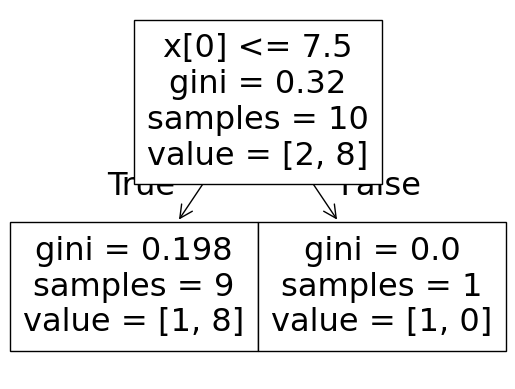

In [213]:
dt3.fit(X,y)
plot_tree(dt3)

<Axes: >

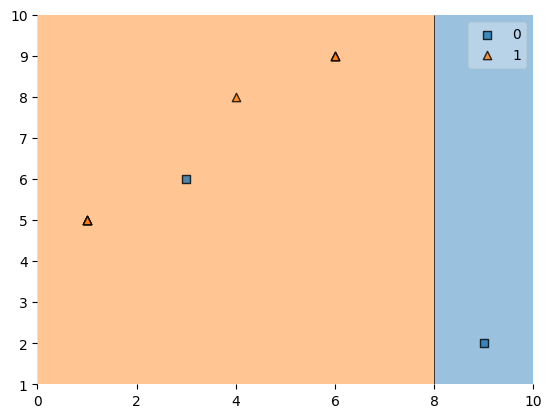

In [214]:
plot_decision_regions(X,y,clf=dt3)

In [216]:
df3['y_pred'] = dt3.predict(X)
df3

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
0,1,5,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
0,1,5,1,0.1,1
5,6,9,1,0.1,1
5,6,9,1,0.1,1
0,1,5,1,0.1,1
5,6,9,1,0.1,1
9,9,2,0,0.1,0


In [217]:
alpha3 = calculate_model_weight(0.1)
alpha3

np.float64(1.0986122886681098)

In [219]:
print(alpha,alpha2,alpha3)

0.4236489301936017 1.0986122886681098 1.0986122886681098


# Prediction

In [220]:
dt1.predict(np.array([1,5]).reshape(1,2))

array([1])

In [221]:
dt2.predict(np.array([1,5]).reshape(1,2))

array([1])

In [222]:
dt3.predict(np.array([1,5]).reshape(1,2))

array([1])

In [223]:
alpha*(1) + alpha2*(1) + alpha3*(1)

np.float64(2.6208735075298213)

In [225]:
np.sign(2.62087) # correct

np.float64(1.0)

In [226]:
# Second prediction  
dt1.predict(np.array([5,1]).reshape(1,2))

array([0])

In [227]:
dt2.predict(np.array([5,1]).reshape(1,2))

array([0])

In [228]:
dt3.predict(np.array([5,1]).reshape(1,2))

array([1])

In [229]:
alpha*(1) + alpha2*(1) + alpha3*(-1)

np.float64(0.4236489301936017)

In [232]:
np.sign(0.42364) #correct

np.float64(1.0)